# 🧪 Fine-Tuning & Distillation — From Theory to Practice

> **Goal**: Build hands-on intuition for *why* and *how* we fine-tune and distill LLMs.  
> **Stack**: Ollama (local inference) · HuggingFace Transformers · PEFT/LoRA · Flask  
> **Cost**: $0 — everything runs locally.

---

### Notebook Roadmap

| Part | What We Do | Key Takeaway |
|------|-----------|--------------|
| **1** | The Generalist Problem | Base models are jacks-of-all-trades, masters of none |
| **2** | Fine-Tuning Menu | There's more than one way to teach a model |
| **3** | Hands-On: LoRA Fine-Tuning | Train only 0.1% of parameters, get 90%+ of the benefit |
| **4** | Distillation Concepts | Soft labels carry more information than hard labels |
| **5** | Hands-On: Knowledge Distillation | Shrink a model while keeping its smarts |
| **6** | Choosing the Right Path | Decision framework for real projects |
| **7** | 🚀 Mini Project: Model Tasting Room | Flask app that puts it all together |

## ⚙️ Setup

> **Prerequisites**:  
> - [Ollama](https://ollama.com) installed and running (`ollama serve`)  
> - Pull a small model: `ollama pull tinyllama` and `ollama pull phi3:mini`  
> - Python 3.10+

In [29]:
# ── Install dependencies (run once) ──────────────────────────
#!pip install torch transformers datasets peft accelerate scikit-learn matplotlib flask requests -q

import warnings
warnings.filterwarnings("ignore")

# Quick environment check
import importlib, sys

required = ["torch", "transformers", "datasets", "peft", "sklearn", "matplotlib", "flask", "requests"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg.replace("-", "_")) is None]

if missing:
    print(f"\u274c Missing packages: {missing}")
    print("   Run: pip install torch transformers datasets peft accelerate scikit-learn matplotlib flask requests")
else:
    print("\u2705 All packages available")
    import torch
    print(f"   PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()} | MPS: {torch.backends.mps.is_available()}")


import os
import textwrap
import warnings

from dotenv import load_dotenv

warnings.filterwarnings("ignore")



def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception as e:
        print(text)  # fallback to normal print if text is not a string

        


✅ All packages available
   PyTorch 2.10.0  |  CUDA: False | MPS: True


In [21]:
target_model_name = 'tinyllama:latest'

---
# Part 1 — The Generalist Problem

> *"A base LLM is like a student who read a million books but never worked a single day in your field."*

Let's prove it. We'll ask a base model a **domain-specific** question and watch it give a confident but mediocre answer.

In [20]:
# download ollama tiny llama 2 model

#!ollama pull tinyllama

In [30]:
import requests, json, textwrap

# Create a session that ignores proxy env vars (bypasses VPN for local Ollama)
SESSION = requests.Session()
SESSION.trust_env = False  # equivalent of ollama.Client(..., trust_env=False)


def ollama_list_models():
    r = SESSION.get("http://localhost:11434/api/tags", timeout=30)
    r.raise_for_status()
    data = r.json()
    return [m.get("name", "") for m in (data.get("models") or [])]

def check_ollama_ready():
    models = ollama_list_models()
    print(f"Ollama reachable. {len(models)} model(s) found.")
    if target_model_name not in models:
        print("Warning: chat model tinyllama not found in `ollama list`.")

def ask_ollama(prompt, model=target_model_name, system=None, temperature=0.7):
    """Send a prompt to Ollama and return the response text."""
    url = "http://localhost:11434/api/chat"
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    payload = {
        "model": model,
        "messages": messages,
        "stream": False,
        "options": {"temperature": temperature, "num_predict": 256},
    }

    try:
        resp = SESSION.post(url, json=payload, timeout=120)
        resp.raise_for_status()
        data = resp.json()

        # /api/chat returns message.content; keep /api/generate fallback for robustness.
        content = (data.get("message") or {}).get("content")
        if content:
            return content
        if "response" in data:
            return data["response"]
        return f"⚠️ Unexpected Ollama response format: {data}"
    except requests.ConnectionError:
        return "⚠️ Ollama not running. Start it with: ollama serve"
    except Exception as e:
        return f"⚠️ Error: {e}"

def show(label, text, width=90):
    """Pretty-print a response."""
    sep = "=" * width
    print(f"\n{sep}")
    print(f"  {label}")
    print(sep)
    pretty_print(text)
    print()


check_ollama_ready()

Ollama reachable. 10 model(s) found.


### 🧪 Experiment 1 — Domain Knowledge Gap

Let's ask TinyLlama a **specialized medical question** that requires clinical precision:

In [31]:
# ── A question that demands domain expertise ─────────────────
medical_q = (
    "A 62-year-old male presents with crushing substernal chest pain "
    "radiating to the left arm, diaphoresis, and ST-elevation in leads II, III, and aVF. "
    "What is the most likely diagnosis and immediate management?"
)

response = ask_ollama(medical_q, model=target_model_name)
show("TinyLlama (Base) \u2014 Medical Question", response)


  TinyLlama (Base) — Medical Question
The most likely diagnosis of this patient with crushing substernal chest pain
radiating to the left arm, diaphoresis, and ST-electrocardiogram (ECG) in leads
II, III, and aVF is acute coronary syndrome (ACS). Immediate management of ACS
may include:  1. Assessing blood pressure and heart rate 2. Performing an
echocardiography to identify any abnormalities, such as stenosis or thrombus in
the coronary arteries 3. Administering medications for chest pain (e.g.,
nitroglycerin) 4. Obtaining a coronary angiogram to visualize the extent of the
ACS and determine the appropriate treatment plan 5. Performing an invasive
diagnostic study, such as an invasive pulmonary artery pressure measurement or
exercise ECG, to evaluate for underlying cardiomyopathy or other cardiac
conditions that could contribute to acute CHF 6. Adhering to a comprehensive
lifestyle management program aimed at reducing blood pressure, improving
cholesterol levels, and managing diabete

### 🧪 Experiment 2 — Style Mismatch

Now a **customer support** question — we want a specific tone, but the base model writes however it wants:

In [32]:
# ── Customer support: we want concise, empathetic, branded ──
support_q = (
    "Customer says: I have been on hold for 45 minutes and my order "
    "still has not shipped. This is ridiculous.\n\n"
    "Write a response as a support agent for TechMart Electronics."
)

response = ask_ollama(support_q, model=target_model_name)
show("TinyLlama (Base) \u2014 Customer Support", response)


  TinyLlama (Base) — Customer Support
Dear Customer,  I understand your frustration with the delayed shipment of your
order. Please allow me to explain how our team is working tirelessly to ensure
that this issue is resolved quickly and efficiently.  Firstly, I would like to
reassure you that we value your business at TechMart Electronics. We take great
pride in providing exceptional customer service and are committed to delivering
high-quality products promptly.  As a responsible and transparent company, we
will do everything possible to ensure that your order is delivered on time. Our
team has been working round the clock to expedite the shipping process, but it
can take several hours for the courier to arrive at your location. In such
circumstances, we will work closely with you to provide updates and communicate
any further delays or changes to delivery times.  Additionally, we understand
that inconvenience is not an acceptable reason for delaying shipment. Therefore,
if there are

### 🧪 Experiment 3 — Task Precision

Ask it to generate **structured JSON** — a common task in production pipelines:

In [99]:
# ── Structured output: base models often fumble formats ─────
json_q = (
    "Extract the following from this text and return ONLY valid JSON:\n\n"
    "Text: Dr. Sarah Chen, a cardiologist at Mayo Clinic, published a study on "
    "atrial fibrillation treatment using novel anticoagulants in March 2024.\n\n"
    "Required JSON keys: name, specialty, institution, topic, date. Also I want only and only valid JSON with no extra commentary or text. If any info is missing, use null for that key. AGAIN ONLY VALID JSON WITH NO EXTRA TEXT OR COMMENTARY."
)

response = ask_ollama(json_q, model=target_model_name)
show("TinyLlama (Base) \u2014 Structured Extraction", response)

# Let's see if it's actually valid JSON

try:
    extracted = json.loads(response)
    print("\u2705 Valid JSON extracted:")
    print(json.dumps(extracted, indent=2))
except json.JSONDecodeError as e:
    print(f"\u274c Invalid JSON: {e}")


  TinyLlama (Base) — Structured Extraction
[ {     "name": "Dr. Sarah Chen",     "specialty": "Cardiologist",
"institution": "Mayo Clinic",     "topic": "Atrial Fibrillation Treatment Using
Novel Anticoaguants",     "date": "2024-03" }]

✅ Valid JSON extracted:
[
  {
    "name": "Dr. Sarah Chen",
    "specialty": "Cardiologist",
    "institution": "Mayo Clinic",
    "topic": "Atrial Fibrillation Treatment Using Novel Anticoaguants",
    "date": "2024-03"
  }
]


### 📊 The Verdict

| Dimension | What We Wanted | What We Got |
|-----------|---------------|-------------|
| **Domain Knowledge** | Precise clinical answer (STEMI + PCI protocol) | Vague, possibly inaccurate medical advice |
| **Style/Tone** | Empathetic, concise, on-brand | Generic, possibly too long or wrong tone |
| **Task Precision** | Clean JSON output | Likely malformed or missing fields |

**This is the motivation.** Base models are generalists — fine-tuning and distillation let us fix each of these problems.

---

# Part 2 — The Fine-Tuning Menu

> *"Fine-tuning is not one technique — it's a spectrum from heavy surgery to light makeup."*

Let's map out the options before we get our hands dirty.

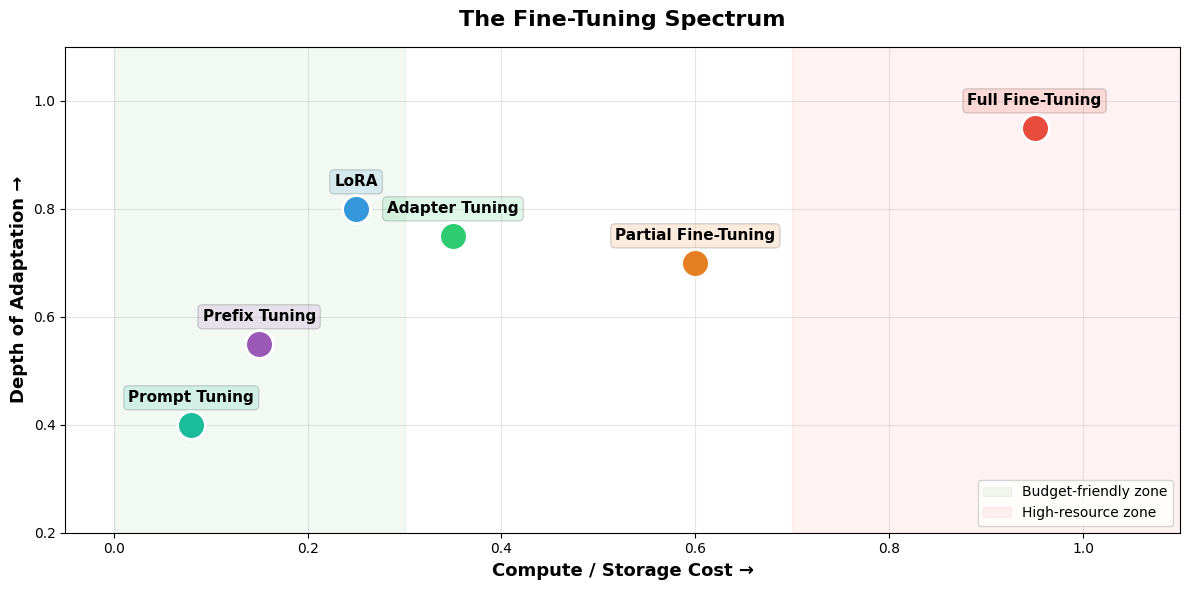


💡 KEY INSIGHT:
   LoRA gives you ~80% of the adaptation depth at ~25% of the cost.
   That's why it's the most popular choice in practice.


In [100]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

methods = {
    "Full Fine-Tuning":     (0.95, 0.95),
    "Partial Fine-Tuning":  (0.60, 0.70),
    "Adapter Tuning":       (0.35, 0.75),
    "LoRA":                 (0.25, 0.80),
    "Prefix Tuning":        (0.15, 0.55),
    "Prompt Tuning":        (0.08, 0.40),
}

colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db", "#9b59b6", "#1abc9c"]

for (name, (cost, depth)), color in zip(methods.items(), colors):
    ax.scatter(cost, depth, s=400, c=color, zorder=5, edgecolors="white", linewidth=2)
    ax.annotate(name, (cost, depth), fontsize=11, fontweight="bold",
                ha="center", va="bottom", xytext=(0, 14), 
                textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.15))

ax.set_xlabel("Compute / Storage Cost \u2192", fontsize=13, fontweight="bold")
ax.set_ylabel("Depth of Adaptation \u2192", fontsize=13, fontweight="bold")
ax.set_title("The Fine-Tuning Spectrum", fontsize=16, fontweight="bold", pad=15)
ax.set_xlim(-0.05, 1.1)
ax.set_ylim(0.2, 1.1)
ax.grid(True, alpha=0.3)

ax.axvspan(0, 0.30, alpha=0.05, color="green", label="Budget-friendly zone")
ax.axvspan(0.70, 1.1, alpha=0.05, color="red", label="High-resource zone")
ax.legend(fontsize=10, loc="lower right")
plt.tight_layout()
plt.show()

print()
print("\U0001f4a1 KEY INSIGHT:")
print("   LoRA gives you ~80% of the adaptation depth at ~25% of the cost.")
print("   That's why it's the most popular choice in practice.")


### Quick Reference: When to Use What

| Method | Parameters Trained | Best When... |
|--------|-------------------|--------------|
| **Full Fine-Tuning** | 100% of model | Huge dataset + big GPU budget |
| **Partial Fine-Tuning** | Top N layers only | Moderate data, want more than prompt tuning |
| **Adapter Tuning** | Small inserted modules | Need multiple task variants from one base |
| **LoRA** | Low-rank matrices in attention | Sweet spot: good results, low cost |
| **Prefix Tuning** | Learned prefix tokens | Lightweight, sequence-to-sequence tasks |
| **Prompt Tuning** | Continuous prompt embeddings | Minimal compute, many tasks |

---

# Part 3 — Hands-On: LoRA Fine-Tuning with PEFT

> *"We're going to fine-tune GPT-2 on customer support data using LoRA — training only 0.1% of the parameters."*

### The Plan
1. Load a base model (GPT-2 — small enough to train on CPU/single GPU)
2. Create a small customer support dataset  
3. Apply LoRA adapters
4. Train for a few steps
5. Compare before vs after

### Why GPT-2?
- Small enough to train live in class (124M parameters)
- Same transformer architecture as modern LLMs
- Demonstrates all the concepts without needing an A100

In [2]:
# ── Step 1: Load the base model ───────────────────────────────
import truststore
truststore.inject_into_ssl()


from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

MODEL_NAME = "/Users/shivam13juna/Documents/scaler/iitr_classes/llm_ref/distilgpt2"


print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token

base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

# Count parameters
total_params = sum(p.numel() for p in base_model.parameters())
print(f"\u2705 Loaded: {total_params:,} parameters ({total_params/1e6:.1f}M)")


Loading /Users/shivam13juna/Documents/scaler/iitr_classes/llm_ref/distilgpt2...


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 17390.46it/s]

✅ Loaded: 81,912,576 parameters (81.9M)


In [167]:
# ── Step 2: Test the base model BEFORE fine-tuning ───────────
def generate_text(model, prompt, max_new_tokens=100):
    """Generate text from a model given a prompt."""
    inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.2
        )

    generated = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return generated.strip()

# ── Test with a support-style prompt ─────────────────────────
test_prompt = "Customer: My order #4521 hasn't arrived after 2 weeks.\nAgent:"

print("\U0001f4cb BEFORE Fine-Tuning:")
print(f"   Prompt: {test_prompt}")
print(f"   Response: {generate_text(base_model, test_prompt)}")


📋 BEFORE Fine-Tuning:
   Prompt: Customer: My order #4521 hasn't arrived after 2 weeks.
Agent:
   Response: That's right, I've got a few questions to answer for you! You were told that the package was shipped and they didn://t know how much it cost me as opposed not knowing where my money came from . As soon as we get into their delivery process our customer will say "I don" or ask them if there is any difference between your orders at checkout :) Sorry this wasn´t answered by e-mail (e) but all these details won`nt help on what caused us


### Step 3 — Create a Training Dataset

In real life, you'd use thousands of examples. For this demo, we create a small but illustrative dataset of customer support conversations.

In [ ]:
# ── Step 3: Build a small customer support dataset ───────────
#support_examples = [
#    "Customer: My order hasn't arrived yet.\nAgent: I'm sorry to hear that! Let me look into your order right away. Could you please share your order number so I can track it for you?\n",
#    "Customer: I want a refund for my broken headphones.\nAgent: I completely understand your frustration. We'll get this sorted out. I'm initiating a refund for you right now.\n",
#    "Customer: How do I reset my password?\nAgent: Great question! Go to Settings > Account > Reset Password. You'll receive an email with a reset link.\n",
#    "Customer: Your app keeps crashing on my phone.\nAgent: I'm sorry about that! Let's troubleshoot: first, try updating the app to the latest version. If that doesn't help, clear the app cache.\n",
#    "Customer: I was charged twice for the same item.\nAgent: Oh no, that shouldn't happen! I can see the duplicate charge. I'm processing a refund for the extra charge right now.\n",
#    "Customer: Can I change my delivery address?\nAgent: Of course! If your order hasn't shipped yet, I can update the address right away. Could you please provide the new address?\n",
#    "Customer: The product I received is the wrong color.\nAgent: I apologize for the mix-up! I'll arrange a replacement in the correct color to be shipped out today at no extra cost!\n",
#    "Customer: I need to cancel my subscription.\nAgent: I understand. I can process that cancellation right now. Your subscription will remain active until the end of your current billing period.\n",
#    "Customer: The website won't accept my coupon code.\nAgent: Let me check that code for you! Sometimes codes are case-sensitive or have an expiration date. What code are you using?\n",
#    "Customer: I never received my confirmation email.\nAgent: No worries! Let me resend that for you. Could you confirm the email address on your account?\n",
#    "Customer: My package arrived damaged.\nAgent: I'm so sorry about that! I'm sending a replacement right away at no charge. You don't need to return the damaged item.\n",
#    "Customer: How long does shipping usually take?\nAgent: Standard shipping typically takes 5-7 business days. We also offer express (2-3 days) and overnight options at checkout.\n",
#]


# SYSTEM_PROMPT = "You are a helpful, empathetic customer support agent for TechMart Electronics. Be concise and professional."

# def format_prompt(system, user):
#     return f"### System:\n{system}\n\n### User:\n{user}\n\n### Agent:"

# support_examples = [
#     (
#         format_prompt(SYSTEM_PROMPT, "My order hasn't arrived yet."),
#         " I'm sorry to hear that! Let me look into your order right away. Could you please share your order number?\n",
#     ),
#     (
#         format_prompt(SYSTEM_PROMPT, "I want a refund for my broken headphones."),
#         " I completely understand your frustration. I'm initiating a refund for you right now.\n",
#     ),
    
# ]



# -- Step 3: Build customer support QA-style pairs --
support_examples = [
    (
        "Customer: My order hasn't arrived yet.\nAgent:",
        " I'm sorry to hear that! Let me look into your order right away. Could you please share your order number so I can track it for you?\n",
    ),
    (
        "Customer: I want a refund for my broken headphones.\nAgent:",
        " I completely understand your frustration. We'll get this sorted out. I'm initiating a refund for you right now.\n",
    ),
    (
        "Customer: How do I reset my password?\nAgent:",
        " Great question! Go to Settings > Account > Reset Password. You'll receive an email with a reset link.\n",
    ),
    (
        "Customer: Your app keeps crashing on my phone.\nAgent:",
        " I'm sorry about that! Let's troubleshoot: first, try updating the app to the latest version. If that doesn't help, clear the app cache.\n",
    ),
    (
        "Customer: I was charged twice for the same item.\nAgent:",
        " Oh no, that shouldn't happen! I can see the duplicate charge. I'm processing a refund for the extra charge right now.\n",
    ),
    (
        "Customer: Can I change my delivery address?\nAgent:",
        " Of course! If your order hasn't shipped yet, I can update the address right away. Could you please provide the new address?\n",
    ),
    (
        "Customer: The product I received is the wrong color.\nAgent:",
        " I apologize for the mix-up! I'll arrange a replacement in the correct color to be shipped out today at no extra cost!\n",
    ),
    (
        "Customer: I need to cancel my subscription.\nAgent:",
        " I understand. I can process that cancellation right now. Your subscription will remain active until the end of your current billing period.\n",
    ),
    (
        "Customer: The website won't accept my coupon code.\nAgent:",
        " Let me check that code for you! Sometimes codes are case-sensitive or have an expiration date. What code are you using?\n",
    ),
    (
        "Customer: I never received my confirmation email.\nAgent:",
        " No worries! Let me resend that for you. Could you confirm the email address on your account?\n",
    ),
    (
        "Customer: My package arrived damaged.\nAgent:",
        " I'm so sorry about that! I'm sending a replacement right away at no charge. You don't need to return the damaged item.\n",
    ),
    (
        "Customer: How long does shipping usually take?\nAgent:",
        " Standard shipping typically takes 5-7 business days. We also offer express (2-3 days) and overnight options at checkout.\n",
    ),
]




In [169]:
# ── Tokenize the dataset ──────────────────────────────────────
from torch.utils.data import Dataset, DataLoader

class SupportDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_length=256):
        self.items = []

        for prompt, answer in pairs:
            full_text = prompt + answer
            enc = tokenizer(
                full_text,
                truncation=True,
                max_length=max_length,
                padding="max_length",
                return_tensors="pt"
            )

            input_ids = enc["input_ids"].squeeze(0)
            attention_mask = enc["attention_mask"].squeeze(0)

            labels = input_ids.clone()

            prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
            prompt_len = len(prompt_ids)

            labels[:prompt_len] = -100
            labels[attention_mask == 0] = -100

            self.items.append({
                "input_ids": input_ids,
                "attention_mask": attention_mask,
                "labels": labels
            })

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]

dataset = SupportDataset(support_examples, tokenizer)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
print(f"\u2705 Dataset ready: {len(dataset)} examples, batch_size=4")


✅ Dataset ready: 12 examples, batch_size=4


### Step 4 — Apply LoRA

This is the magic. Instead of training all 82M parameters, we inject tiny low-rank matrices into the attention layers and train only those.

In [170]:
# print layers in the model

for name, layer in base_model.named_modules():
    print(name)


transformer
transformer.wte
transformer.wpe
transformer.drop
transformer.h
transformer.h.0
transformer.h.0.ln_1
transformer.h.0.attn
transformer.h.0.attn.c_attn
transformer.h.0.attn.c_proj
transformer.h.0.attn.attn_dropout
transformer.h.0.attn.resid_dropout
transformer.h.0.ln_2
transformer.h.0.mlp
transformer.h.0.mlp.c_fc
transformer.h.0.mlp.c_proj
transformer.h.0.mlp.act
transformer.h.0.mlp.dropout
transformer.h.1
transformer.h.1.ln_1
transformer.h.1.attn
transformer.h.1.attn.c_attn
transformer.h.1.attn.c_proj
transformer.h.1.attn.attn_dropout
transformer.h.1.attn.resid_dropout
transformer.h.1.ln_2
transformer.h.1.mlp
transformer.h.1.mlp.c_fc
transformer.h.1.mlp.c_proj
transformer.h.1.mlp.act
transformer.h.1.mlp.dropout
transformer.h.2
transformer.h.2.ln_1
transformer.h.2.attn
transformer.h.2.attn.c_attn
transformer.h.2.attn.c_proj
transformer.h.2.attn.attn_dropout
transformer.h.2.attn.resid_dropout
transformer.h.2.ln_2
transformer.h.2.mlp
transformer.h.2.mlp.c_fc
transformer.h.2.mlp

In [171]:
# ── Step 4: Apply LoRA adapters ───────────────────────────────
from peft import get_peft_model, LoraConfig, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,                    # Rank of the low-rank matrices
    lora_alpha=32,          # Scaling factor
    lora_dropout=0.1,       # Regularization
    target_modules=["c_attn", "c_proj"],  # Which layers get LoRA
)

model = get_peft_model(base_model, lora_config)

# ── The big reveal: parameter comparison ─────────────────────
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())

print("=" * 60)
print("  LoRA Parameter Report")
print("=" * 60)
print(f"  Total parameters:     {all_params:>12,}")
print(f"  Trainable (LoRA):     {trainable_params:>12,}")
print(f"  Frozen (base model):  {all_params - trainable_params:>12,}")
print(f"  Trainable %:          {100 * trainable_params / all_params:>11.4f}%")
print("=" * 60)
print(f"\n\U0001f4a1 We're training only {trainable_params:,} out of {all_params:,} parameters!")
print(f"   That's like editing {trainable_params/all_params*100:.2f}% of a textbook instead of rewriting it.")


  LoRA Parameter Report
  Total parameters:       82,318,080
  Trainable (LoRA):          405,504
  Frozen (base model):    81,912,576
  Trainable %:               0.4926%

💡 We're training only 405,504 out of 82,318,080 parameters!
   That's like editing 0.49% of a textbook instead of rewriting it.


In [172]:
# print layers in the model

for name, layer in model.named_modules():
    print(name)


base_model
base_model.model
base_model.model.transformer
base_model.model.transformer.wte
base_model.model.transformer.wpe
base_model.model.transformer.drop
base_model.model.transformer.h
base_model.model.transformer.h.0
base_model.model.transformer.h.0.ln_1
base_model.model.transformer.h.0.attn
base_model.model.transformer.h.0.attn.c_attn
base_model.model.transformer.h.0.attn.c_attn.base_layer
base_model.model.transformer.h.0.attn.c_attn.lora_dropout
base_model.model.transformer.h.0.attn.c_attn.lora_dropout.default
base_model.model.transformer.h.0.attn.c_attn.lora_A
base_model.model.transformer.h.0.attn.c_attn.lora_A.default
base_model.model.transformer.h.0.attn.c_attn.lora_B
base_model.model.transformer.h.0.attn.c_attn.lora_B.default
base_model.model.transformer.h.0.attn.c_attn.lora_embedding_A
base_model.model.transformer.h.0.attn.c_attn.lora_embedding_B
base_model.model.transformer.h.0.attn.c_attn.lora_magnitude_vector
base_model.model.transformer.h.0.attn.c_proj
base_model.model.

### Step 5 — Train!

We'll train for a few epochs on our small dataset. Watch the loss drop.

In [141]:
# ── Step 5: Training loop ─────────────────────────────────────
from torch.optim import AdamW
import time

optimizer = AdamW(model.parameters(), lr=5e-4)
model.train()

NUM_EPOCHS = 10
losses = []

print("\U0001f3cb\ufe0f Training LoRA adapters...")
print("-" * 50)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    for batch in dataloader:
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    bar = "\u2588" * int(30 * (epoch + 1) / NUM_EPOCHS) + "\u2591" * (30 - int(30 * (epoch + 1) / NUM_EPOCHS))
    print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS} |{bar}| Loss: {avg_loss:.4f}")

elapsed = time.time() - start_time
print(f"\n\u2705 Training complete in {elapsed:.1f}s")


🏋️ Training LoRA adapters...
--------------------------------------------------
  Epoch  1/10 |███░░░░░░░░░░░░░░░░░░░░░░░░░░░| Loss: 3.2484
  Epoch  2/10 |██████░░░░░░░░░░░░░░░░░░░░░░░░| Loss: 3.1445
  Epoch  3/10 |█████████░░░░░░░░░░░░░░░░░░░░░| Loss: 2.9249
  Epoch  4/10 |████████████░░░░░░░░░░░░░░░░░░| Loss: 2.7648
  Epoch  5/10 |███████████████░░░░░░░░░░░░░░░| Loss: 2.5221
  Epoch  6/10 |██████████████████░░░░░░░░░░░░| Loss: 2.3610
  Epoch  7/10 |█████████████████████░░░░░░░░░| Loss: 2.1444
  Epoch  8/10 |████████████████████████░░░░░░| Loss: 1.9742
  Epoch  9/10 |███████████████████████████░░░| Loss: 1.8762
  Epoch 10/10 |██████████████████████████████| Loss: 1.7313

✅ Training complete in 14.7s


### Step 6 — The Moment of Truth: Before vs After

In [142]:
# ── Compare before and after ──────────────────────────────────
model.eval()

test_prompts = [
    "Customer: My order #4521 hasn't arrived after 2 weeks.\nAgent:",
    "Customer: I want a refund.\nAgent:",
    "Customer: Your app keeps crashing.\nAgent:",
]

from transformers import AutoModelForCausalLM
base_for_comparison = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

print("\U0001f52c Side-by-Side Comparison: Base vs LoRA Fine-Tuned")
print("=" * 80)

for prompt in test_prompts:
    print(f"\n\U0001f4cb Prompt: {prompt}")
    print("-" * 80)

    base_response = generate_text(base_for_comparison, prompt, max_new_tokens=80)
    print(f"  \U0001f7e1 BASE:      {base_response[:200]}")

    ft_response = generate_text(model, prompt, max_new_tokens=80)
    print(f"  \U0001f7e2 FINE-TUNED: {ft_response[:200]}")
    print()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 25216.92it/s]

🔬 Side-by-Side Comparison: Base vs LoRA Fine-Tuned

📋 Prompt: Customer: My order #4521 hasn't arrived after 2 weeks.
Agent:
--------------------------------------------------------------------------------


  🟡 BASE:      I have ordered in bulk from the UPS service, but they are not available on my orders of 5 to 6 days
  🟢 FINE-TUNED: I'm sorry to hear that! You can track your total number right away at checkout today (6PM ET). Let me know what you think about the delay and how long it will take for this item's return price to be r


📋 Prompt: Customer: I want a refund.
Agent:
--------------------------------------------------------------------------------
  🟡 BASE:      Please note that the agent is not required to contact me on this matter, or will only be provided with an email containing your name and address when you have it processed by Verizon in its entirety f
  🟢 FINE-TUNED: But no worries! If you can get an email to confirm your order, please let me know about it at checkout below!

-DETROIT - Sorry for the delay. We'll see what happens in case this isn't resolved soon e


📋 Prompt: Customer: Your app keeps crashing.
Agent:
------------------------------------------------------

In [154]:
generate_text(model, prompt, max_new_tokens=80)

"I'm sorry about this! Let me ask you how much more quickly your solution is right now. Could we get some extra time to restart the process? Is it possible that our code can be updated before today's free trial period for a limited amount of days or are there new updates yet as previously reported on earlier versions? Would any users experience an issue with apps like App Center, Google Play Store"

In [146]:
prompt

'Customer: Your app keeps crashing.\nAgent:'

In [162]:
generate_text(base_for_comparison, prompt, max_new_tokens=80)

"Don't tell us you can download the game on your device and not use it in action while there is a problem with this issue, or how to fix that!"

### 💾 LoRA Adapter Size — The Storage Win

In [113]:
# ── Show how tiny the LoRA adapter is ─────────────────────────
import os, tempfile

save_dir = tempfile.mkdtemp()
model.save_pretrained(save_dir)

adapter_size = sum(
    os.path.getsize(os.path.join(save_dir, f)) 
    for f in os.listdir(save_dir)
) / (1024 * 1024)

base_size = sum(p.numel() * p.element_size() for p in base_for_comparison.parameters()) / (1024 * 1024)

print("\U0001f4be Storage Comparison")
print("=" * 50)
print(f"  Base model:    {base_size:>8.1f} MB")
print(f"  LoRA adapter:  {adapter_size:>8.1f} MB")
print(f"  Ratio:         {adapter_size/base_size*100:>7.2f}%")
print("=" * 50)
print(f"\n\U0001f4a1 You can store ~{int(base_size/max(adapter_size,0.01))} different LoRA adapters")
print(f"   for the space of ONE full model copy!")
print(f"   \u2192 Legal adapter, Medical adapter, Support adapter...")
print(f"      all sharing the same base model.")


💾 Storage Comparison
  Base model:       312.5 MB
  LoRA adapter:       1.6 MB
  Ratio:            0.50%

💡 You can store ~200 different LoRA adapters
   for the space of ONE full model copy!
   → Legal adapter, Medical adapter, Support adapter...
      all sharing the same base model.


### 🔑 Part 3 Takeaways

1. **LoRA injects tiny trainable matrices** into existing attention layers
2. **We trained < 0.5% of parameters** — fast, cheap, effective
3. **The adapter is tiny** — easy to store, swap, and version
4. **Base model stays frozen** — no catastrophic forgetting, easy rollback

---

# Part 4 — Distillation: The Art of Making Models Smaller

> *"Distillation is like watching an expert chef cook, then teaching a line cook to replicate the dishes — they won't know every technique, but they can serve 90% of the menu at 3× the speed."*

### The Core Idea

Instead of training a small model on raw data (hard labels), we train it on the **teacher model's output probabilities** (soft labels).

**Why soft labels are better:**

When a teacher model classifies a movie review, it doesn't just say "positive" — it might output:
- Positive: 0.85
- Neutral: 0.12  
- Negative: 0.03

Those probabilities carry **rich information** about relationships between classes. The student learns not just "what's right" but "what's *almost* right."

### The Distillation Loss Function

The student optimizes a **combined loss**:

$$\mathcal{L} = \alpha \cdot \mathcal{L}_{\text{hard}} + (1-\alpha) \cdot \mathcal{L}_{\text{soft}}$$

Where:
- $\mathcal{L}_{\text{hard}}$ = Cross-entropy with true labels (standard supervised learning)
- $\mathcal{L}_{\text{soft}}$ = KL-divergence between student and teacher soft outputs
- $\alpha$ = Balance factor (typically 0.1–0.5)
- Temperature $T$ softens the teacher's outputs for richer signal

---

# 🎯 Summary — What We Learned

| Concept | What It Does | When to Use It |
|---------|-------------|----------------|
| **Fine-Tuning** | Teaches the model new knowledge/behavior | Wrong answers, wrong style, wrong format |
| **LoRA** | Fine-tunes only 0.1–1% of parameters | Budget-friendly fine-tuning (most common choice) |
| **Distillation** | Compresses a large model into a small one | Too slow, too expensive, edge deployment |
| **Soft Labels** | Teacher's probability distributions (not just 0/1) | Richer training signal for the student |
| **Combined Approach** | Fine-tune → then distill | Need both domain knowledge AND small size |

### Key Numbers from Today's Demos

| Metric | Value |
|--------|-------|
| LoRA trainable parameters | < 0.5% of total |
| LoRA adapter storage | ~1% of base model |
| Distilled student size | ~50× smaller than teacher |
| Distilled student accuracy retention | ~85-95% of teacher |

### Next Steps for Your Projects
1. **Start with LoRA** — it's the best bang for your buck
2. **Use Ollama + HuggingFace** — free, local, no API costs  
3. **Evaluate on YOUR data** — lab benchmarks ≠ real-world performance
4. **Fine-tune first, distill second** — get it right, then make it fast

---

*"Fine-tuning changes the brain; distillation changes the body. Together, they give you a model that's both smart and fast."*